# Validation of Isotropic Gaussian on SO(3)

In [1]:
%pylab inline
import jax.numpy as jnp
import jax
from jaxlie import SO3
from so3dm.distributions.isotropic_gaussian import IsotropicGaussianSO3, _isotropic_gaussian_so3_small, _isotropic_gaussian_so3

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


## Verify function f

Here we test that the approximation matches well with the series

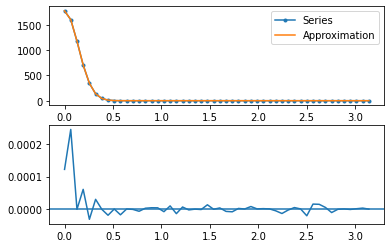

In [2]:
theta = jnp.linspace(0, pi)
scale = 0.1
lmax = 100

subplot(211)
plot(theta, _isotropic_gaussian_so3(theta, scale, lmax), '.-', label='Series')
plot(theta, _isotropic_gaussian_so3_small(theta, scale),  label='Approximation')
legend()

subplot(212)
plot(theta, (_isotropic_gaussian_so3_small(theta, scale) - _isotropic_gaussian_so3(theta, scale, lmax)))
axhline(0)

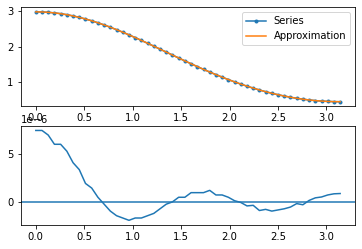

In [3]:
theta = jnp.linspace(0, pi)
scale = 0.9
lmax = 3

subplot(211)
plot(theta, _isotropic_gaussian_so3(theta, scale, lmax), '.-', label='Series')
plot(theta, _isotropic_gaussian_so3_small(theta, scale),  label='Approximation')
legend()

subplot(212)
plot(theta, (_isotropic_gaussian_so3_small(theta, scale) - _isotropic_gaussian_so3(theta, scale, lmax)))
axhline(0)

## Verify that we recover something similar to a Gaussian for very small dispersion

According to https://arxiv.org/abs/2206.08321, we should see something similar to a gaussian

In [4]:
import tensorflow_probability as tfp; tfp = tfp.substrates.jax
tfd = tfp.distributions

/home/francois/.local/lib/python3.10/site-packages/jax/_src/numpy/lax_numpy.py:1806: UserWarning: Explicitly requested dtype <class 'numpy.float64'> requested in array is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  lax_internal._check_user_dtype_supported(dtype, "array")
/home/francois/.local/lib/python3.10/site-packages/jax/_src/numpy/lax_numpy.py:4457: UserWarning: Explicitly requested dtype <class 'numpy.float64'> requested in astype is not available, and will be truncated to dtype float32. To enable more dtypes, set the jax_enable_x64 configuration option or the JAX_ENABLE_X64 shell environment variable. See https://github.com/google/jax#current-gotchas for more.
  lax_internal._check_user_dtype_supported(dtype, "astype")


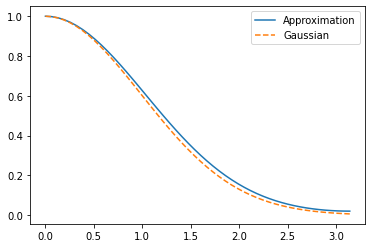

In [5]:
scale = 0.7
scale_gaussian = sqrt(2)*scale
theta = jnp.linspace(0, pi)

plot(theta, _isotropic_gaussian_so3_small(theta, scale)/_isotropic_gaussian_so3_small(theta, scale).max(),  label='Approximation')
plot(theta, tfd.Normal(0, scale_gaussian).prob(theta)/tfd.Normal(0, scale_gaussian).prob(theta).max(), '--',  label='Gaussian')
legend()

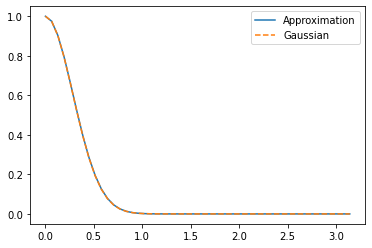

In [6]:
scale = 0.2
scale_gaussian = sqrt(2)*scale
theta = jnp.linspace(0, pi)

plot(theta, _isotropic_gaussian_so3_small(theta, scale)/_isotropic_gaussian_so3_small(theta, scale).max(),  label='Approximation')
plot(theta, tfd.Normal(0, scale_gaussian).prob(theta)/tfd.Normal(0, scale_gaussian).prob(theta).max(), '--',  label='Gaussian')
legend()

## Checking the sampling

In [7]:
dist = IsotropicGaussianSO3(SO3.identity(), 0.1)
samples = dist.sample(1024, seed=jax.random.PRNGKey(0))

In [8]:
samples

DeviceArray([[ 0.9957812 , -0.02018663,  0.01465022, -0.0883047 ],
             [ 0.9995942 , -0.00199915, -0.01604257,  0.02345193],
             [ 0.997948  ,  0.06102636, -0.01659244,  0.01001197],
             ...,
             [ 0.9978874 ,  0.0361054 ,  0.02030388,  0.05004982],
             [ 0.99542946, -0.01916886, -0.03541163,  0.0865956 ],
             [ 0.997483  , -0.057759  , -0.00442982, -0.04088908]],            dtype=float32)

In [9]:
# Let's look at the distribution of axis angles
angles = jnp.linalg.norm(jax.vmap(lambda x: SO3(x).log())(samples),axis=-1)

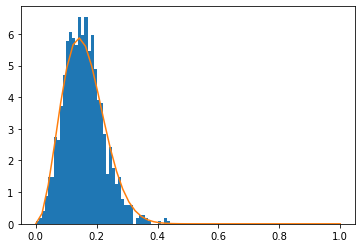

In [10]:
theta = jnp.linspace(0, 1)
hist(angles,100, density=True, range=[0,1]);
plot(theta, (1 - cos(theta))/pi*_isotropic_gaussian_so3_small(theta, 0.1/sqrt(2)))

## Visualisation of the sampled distribution

In [13]:
from so3dm.plotting import visualize_so3_probabilities

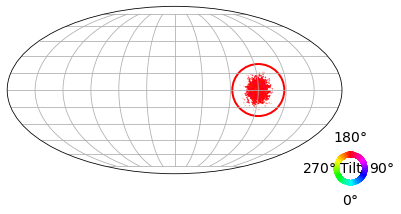

In [31]:
center = SO3.from_x_radians(pi)
dist = IsotropicGaussianSO3(center, 0.1)

samples = dist.sample(1000, seed=jax.random.PRNGKey(0))
prob = jnp.exp(dist.log_prob(samples));

visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(samples),
    0.001*prob/prob.max(),
    rotations_gt=center.as_matrix());

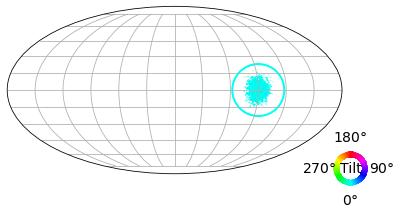

In [32]:
center = SO3.from_x_radians(0)
dist = IsotropicGaussianSO3(center, 0.1)

samples = dist.sample(1000, seed=jax.random.PRNGKey(0))
prob = jnp.exp(dist.log_prob(samples));

visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(samples),
    0.001*prob/prob.max(),
    rotations_gt=center.as_matrix());

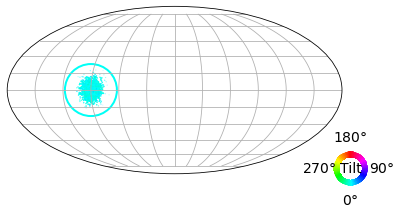

In [34]:
center = SO3.from_z_radians(pi)
dist = IsotropicGaussianSO3(center, 0.1)

samples = dist.sample(1000, seed=jax.random.PRNGKey(0))
prob = jnp.exp(dist.log_prob(samples));

visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(samples),
    0.001*prob/prob.max(),
    rotations_gt=center.as_matrix());

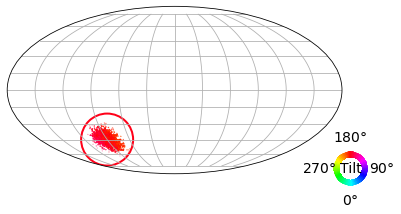

In [44]:
center = SO3.from_y_radians(3*pi/4)
dist = IsotropicGaussianSO3(center, 0.1)

samples = dist.sample(1000, seed=jax.random.PRNGKey(0))
prob = jnp.exp(dist.log_prob(samples));

visualize_so3_probabilities(
    jax.vmap(lambda x: SO3(x).as_matrix())(samples),
    0.001*prob/prob.max(),
    rotations_gt=center.as_matrix());